# 06 — Multi-seed robustness of FedProx under heterogeneity

Notebook 05 produced a detailed seed-42 diagnostic study. This notebook asks whether its FedAvg/FedProx finding survives independently generated client populations.

**Primary question**

> Does moderate FedProx (`mu = 0.1`) consistently improve final performance, worst-client performance, or convergence relative to FedAvg (`mu = 0`), without excessively suppressing client updates?

Each seed defines one complete simulated federated environment: one Dirichlet partition, client split, initialization, and minibatch schedule. All `mu` conditions within a seed share that environment. Therefore, the seed—not a client, round, or update—is the experimental unit.

With three seeds, conclusions are descriptive: report direction, size, variability, and the number of seeds improved. Do not claim statistical significance.

## 1. Imports and environment

Run this notebook from the repository or a child directory. The setup locates the repository root automatically.

In [1]:
from __future__ import annotations

import copy
import inspect
import json
import math
import random
import sys
import time
from dataclasses import asdict, dataclass, replace
from pathlib import Path
from typing import Any, Callable, Dict, Iterable, Mapping, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")

Python: 3.13.9
PyTorch: 2.13.0+cpu
Device: cpu


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not find the repository root. Open the notebook inside the cloned repository."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity


### Repository integration cell

This is the only import cell that may need a small path-name adjustment if the repository has renamed a module. Keep all such adjustments here.

In [3]:
# Adjust only these imports if your current src/ module names differ.
from src.data import partition_dirichlet, split_client_indices

try:
    from src.models import SimpleMLP
except ImportError:
    from src.model import SimpleMLP

# Notebook 05's runner is imported for reuse. Its signature is printed below
# so that TODO 2 can be connected without guessing.
from src.experiment import run_experiment

print("partition_dirichlet", inspect.signature(partition_dirichlet))
print("split_client_indices", inspect.signature(split_client_indices))
print("SimpleMLP", inspect.signature(SimpleMLP))
print("run_experiment", inspect.signature(run_experiment))

partition_dirichlet (train_ds, num_clients: int, alpha: float, seed: int)
split_client_indices (client_indices, train_fraction=0.8, validation_fraction=0.1, seed=42)
SimpleMLP (num_inputs, num_classes)
run_experiment (config, mu_values, initial_model, train_ds, client_train_indices, validation_loaders, loss_fn, device, verbose: bool = False)


## 2. Frozen experiment configuration

Do not change the seed list or `mu` values after viewing results. If a field differs from Notebook 05, change it now and document why.

In [4]:
@dataclass(frozen=True)
class MultiSeedConfig:
    seeds: Tuple[int, ...] = (42, 43, 44)
    mu_values: Tuple[float, ...] = (0.0, 0.1, 1.0)

    num_clients: int = 5
    alpha: float = 0.1
    local_epochs: int = 5
    num_rounds: int = 20
    batch_size: int = 64
    learning_rate: float = 0.01

    validation_fraction: float = 0.1
    test_fraction: float = 0.1
    num_workers: int = 0

    results_dir: Path = PROJECT_ROOT / "results" / "multiseed_fedprox"


CONFIG = MultiSeedConfig()
CONFIG.results_dir.mkdir(parents=True, exist_ok=True)
CONFIG

MultiSeedConfig(seeds=(42, 43, 44), mu_values=(0.0, 0.1, 1.0), num_clients=5, alpha=0.1, local_epochs=5, num_rounds=20, batch_size=64, learning_rate=0.01, validation_fraction=0.1, test_fraction=0.1, num_workers=0, results_dir=WindowsPath('D:/HKU/New folder/federated-learning-under-heterogeneity-final/federated-learning-under-heterogeneity/results/multiseed_fedprox'))

In [5]:
def json_ready(value: Any) -> Any:
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, tuple):
        return list(value)
    return value


config_payload = {key: json_ready(value) for key, value in asdict(CONFIG).items()}
with (CONFIG.results_dir / "config.json").open("w", encoding="utf-8") as handle:
    json.dump(config_payload, handle, indent=2)

print(json.dumps(config_payload, indent=2))

{
  "seeds": [
    42,
    43,
    44
  ],
  "mu_values": [
    0.0,
    0.1,
    1.0
  ],
  "num_clients": 5,
  "alpha": 0.1,
  "local_epochs": 5,
  "num_rounds": 20,
  "batch_size": 64,
  "learning_rate": 0.01,
  "validation_fraction": 0.1,
  "test_fraction": 0.1,
  "num_workers": 0,
  "results_dir": "D:\\HKU\\New folder\\federated-learning-under-heterogeneity-final\\federated-learning-under-heterogeneity\\results\\multiseed_fedprox"
}


## 3. Load the dataset exactly as in Notebook 05

The default below uses normalized MNIST. If Notebook 05 used a different transform or dataset-loading helper, replace this single cell so the comparison remains valid.

In [6]:
from torchvision import datasets, transforms

MNIST_TRANSFORM = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

DATASET_DIR = PROJECT_ROOT / "datasets"
train_dataset = datasets.MNIST(
    root=DATASET_DIR, train=True, download=True, transform=MNIST_TRANSFORM
)
global_test_dataset = datasets.MNIST(
    root=DATASET_DIR, train=False, download=True, transform=MNIST_TRANSFORM
)

print(len(train_dataset), len(global_test_dataset))

60000 10000


## 4. Experiment data structures

Store indices and initial weights—not active DataLoaders. Iterating a DataLoader mutates its generator state.

In [22]:
@dataclass
class SeedArtifacts:
    seed: int
    partition_indices: Dict[int, list[int]]
    train_indices: Dict[int, list[int]]
    validation_indices: Dict[int, list[int]]
    test_indices: Dict[int, list[int]]
    initial_state_dict: Dict[str, torch.Tensor]
    client_label_counts: Dict[int, Dict[int, int]]

@dataclass
class ConditionResult:
    seed: int
    mu: float
    final_model: nn.Module

    performance_history: pd.DataFrame
    client_performance_history: pd.DataFrame
    client_diagnostics: pd.DataFrame
    pairwise_diagnostics: pd.DataFrame
    round_diagnostics: pd.DataFrame

    runtime_seconds: float

## 5. Reusable utilities (already implemented)

In [8]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def clone_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }


def state_dict_vector(state_dict: Mapping[str, torch.Tensor]) -> torch.Tensor:
    return torch.cat([tensor.detach().cpu().reshape(-1) for tensor in state_dict.values()])


def labels_from_dataset(dataset: Dataset) -> np.ndarray:
    if hasattr(dataset, "targets"):
        targets = dataset.targets
        if isinstance(targets, torch.Tensor):
            return targets.detach().cpu().numpy()
        return np.asarray(targets)
    return np.asarray([int(dataset[index][1]) for index in range(len(dataset))])


def count_client_labels(
    dataset: Dataset, partition_indices: Mapping[int, Sequence[int]]
) -> Dict[int, Dict[int, int]]:
    labels = labels_from_dataset(dataset)
    result: Dict[int, Dict[int, int]] = {}
    for client_id, indices in partition_indices.items():
        values, counts = np.unique(labels[np.asarray(indices)], return_counts=True)
        result[int(client_id)] = {int(v): int(c) for v, c in zip(values, counts)}
    return result

## 6. TODO 1 — Prepare one seed's immutable artifacts

This is genuinely new. Complete only the marked calls using the signatures printed in the integration cell. The function must not accept `mu`.

In [9]:
import inspect
print(inspect.signature(split_client_indices))
print(inspect.getsource(split_client_indices))

(client_indices, train_fraction=0.8, validation_fraction=0.1, seed=42)
def split_client_indices(client_indices, train_fraction=0.8, validation_fraction=0.1, seed=42):
    if not (0 < train_fraction and train_fraction < 1 and 0 <= validation_fraction and validation_fraction < 1 and train_fraction + validation_fraction < 1):
        raise ValueError("invalid fraction")
    client_train_indices = {}
    client_validation_indices = {}
    client_test_indices = {}

    for client_id, indices in client_indices.items():
        normalized_indices = (
            torch.as_tensor(indices, dtype=torch.long)
            .cpu()
            .tolist()
        )
        rng = np.random.default_rng(seed + int(client_id))
        shuffled_indices = rng.permutation(
            np.asarray(normalized_indices)
        ).tolist()
        num_examples = len(shuffled_indices)
        num_train = int(num_examples * train_fraction)
        num_validation = int(num_examples * validation_fraction)
        train_

In [10]:
def prepare_seed_artifacts(
    seed: int,
    dataset: Dataset,
    config: MultiSeedConfig,
) -> SeedArtifacts:
    set_all_seeds(seed)

    partition_indices = partition_dirichlet(train_ds=dataset, num_clients=config.num_clients, alpha=config.alpha, seed=seed)

    client_train_indices, client_validation_indices, client_test_indices = split_client_indices(client_indices=partition_indices, train_fraction=0.8, validation_fraction=0.1, seed=seed)
    set_all_seeds(seed)
    initial_model = SimpleMLP(784,10)

    return SeedArtifacts(
        seed=seed,
        partition_indices={int(k): list(map(int, v)) for k, v in partition_indices.items()},
        train_indices=client_train_indices,
        validation_indices=client_validation_indices,
        test_indices=client_test_indices,
        initial_state_dict=clone_state_dict(initial_model),
        client_label_counts=count_client_labels(dataset, partition_indices),
    )

## 7. Fresh condition loaders

Every condition gets newly constructed training loaders with the same per-client generator seeds. Validation and test loaders are deterministic and unshuffled.

In [11]:
def loaders_from_indices(
    dataset: Dataset,
    indices_by_client: Mapping[int, Sequence[int]],
    *,
    batch_size: int,
    shuffle: bool,
    seed: int,
    num_workers: int = 0,
) -> Dict[int, DataLoader]:
    loaders: Dict[int, DataLoader] = {}
    for client_id in sorted(indices_by_client):
        generator = torch.Generator()
        generator.manual_seed(seed + int(client_id))
        loaders[int(client_id)] = DataLoader(
            Subset(dataset, list(indices_by_client[client_id])),
            batch_size=batch_size,
            shuffle=shuffle,
            generator=generator if shuffle else None,
            num_workers=num_workers,
        )
    return loaders


def build_condition_loaders(
    artifacts: SeedArtifacts,
    dataset: Dataset,
    config: MultiSeedConfig,
) -> tuple[Dict[int, DataLoader], Dict[int, DataLoader], Dict[int, DataLoader]]:
    common = dict(
        dataset=dataset,
        batch_size=config.batch_size,
        seed=artifacts.seed,
        num_workers=config.num_workers,
    )
    train_loaders = loaders_from_indices(
        indices_by_client=artifacts.train_indices, shuffle=True, **common
    )
    validation_loaders = loaders_from_indices(
        indices_by_client=artifacts.validation_indices, shuffle=False, **common
    )
    test_loaders = loaders_from_indices(
        indices_by_client=artifacts.test_indices, shuffle=False, **common
    )
    return train_loaders, validation_loaders, test_loaders

## 8. Reproducibility checks

These checks use temporary probe loaders, never the loaders used for training.

In [12]:
def assert_index_dict_equal(left: Mapping[int, list[int]], right: Mapping[int, list[int]]) -> None:
    assert set(left) == set(right)
    for client_id in left:
        assert left[client_id] == right[client_id]


def assert_split_integrity(artifacts: SeedArtifacts) -> None:
    for client_id in artifacts.partition_indices:
        full = set(artifacts.partition_indices[client_id])
        train = set(artifacts.train_indices[client_id])
        validation = set(artifacts.validation_indices[client_id])
        test = set(artifacts.test_indices[client_id])

        assert train.isdisjoint(validation)
        assert train.isdisjoint(test)
        assert validation.isdisjoint(test)
        assert train | validation | test == full


def batch_fingerprints(loaders: Mapping[int, DataLoader], num_batches: int = 3) -> Dict[int, list]:
    fingerprints: Dict[int, list] = {}
    for client_id, loader in loaders.items():
        items = []
        for batch_index, (inputs, targets) in enumerate(loader):
            if batch_index >= num_batches:
                break
            items.append((inputs.detach().cpu().clone(), targets.detach().cpu().clone()))
        fingerprints[int(client_id)] = items
    return fingerprints


def fingerprints_equal(left: Mapping[int, list], right: Mapping[int, list]) -> bool:
    if set(left) != set(right):
        return False
    for client_id in left:
        if len(left[client_id]) != len(right[client_id]):
            return False
        for (x_left, y_left), (x_right, y_right) in zip(left[client_id], right[client_id]):
            if not torch.equal(x_left, x_right) or not torch.equal(y_left, y_right):
                return False
    return True


def run_reproducibility_checks(dataset: Dataset, config: MultiSeedConfig) -> None:
    seed_a, seed_b = config.seeds[:2]
    a1 = prepare_seed_artifacts(seed_a, dataset, config)
    a2 = prepare_seed_artifacts(seed_a, dataset, config)
    b = prepare_seed_artifacts(seed_b, dataset, config)

    for field in ("partition_indices", "train_indices", "validation_indices", "test_indices"):
        assert_index_dict_equal(getattr(a1, field), getattr(a2, field))

    assert any(
        a1.partition_indices[cid] != b.partition_indices.get(cid, [])
        for cid in a1.partition_indices
    )

    assert_split_integrity(a1)
    assert_split_integrity(b)

    assert torch.equal(
        state_dict_vector(a1.initial_state_dict),
        state_dict_vector(a2.initial_state_dict),
    )
    assert not torch.equal(
        state_dict_vector(a1.initial_state_dict),
        state_dict_vector(b.initial_state_dict),
    )

    a_train_1, _, _ = build_condition_loaders(a1, dataset, config)
    a_train_2, _, _ = build_condition_loaders(a2, dataset, config)
    b_train, _, _ = build_condition_loaders(b, dataset, config)

    a_fp_1 = batch_fingerprints(a_train_1)
    a_fp_2 = batch_fingerprints(a_train_2)
    b_fp = batch_fingerprints(b_train)

    assert fingerprints_equal(a_fp_1, a_fp_2)
    assert not fingerprints_equal(a_fp_1, b_fp)

    print("All reproducibility checks passed.")


run_reproducibility_checks(train_dataset, CONFIG)

All reproducibility checks passed.


## 9. Partition audit

In [13]:
def partition_audit_frame(artifacts: SeedArtifacts) -> pd.DataFrame:
    rows = []
    for client_id, counts in artifacts.client_label_counts.items():
        total = sum(counts.values())
        dominant_label = max(counts, key=counts.get)
        row = {
            "seed": artifacts.seed,
            "client_id": client_id,
            "samples": total,
            "dominant_label": dominant_label,
            "dominant_label_fraction": counts[dominant_label] / total,
        }
        row.update({f"label_{label}": counts.get(label, 0) for label in range(10)})
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["seed", "client_id"]).reset_index(drop=True)


def plot_partition_heatmap(audit_df: pd.DataFrame, seed: int) -> None:
    label_columns = [f"label_{label}" for label in range(10)]
    matrix = audit_df.set_index("client_id")[label_columns].to_numpy()
    proportions = matrix / matrix.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(9, 3.5))
    image = ax.imshow(proportions, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"Client label proportions — seed {seed}")
    ax.set_xlabel("MNIST label")
    ax.set_ylabel("Client")
    ax.set_xticks(range(10), range(10))
    ax.set_yticks(range(len(audit_df)), audit_df["client_id"].tolist())
    fig.colorbar(image, ax=ax, label="Within-client proportion")
    plt.tight_layout()
    plt.show()

,seed,client_id,samples,dominant_label,dominant_label_fraction,label_0,label_1,label_2,label_3,label_4,label_5,label_6,label_7,label_8,label_9
0,42,0,8505,3,0.649735,7,0,0,5526,16,0,15,756,2182,3
1,42,1,8904,8,0.411950,0,91,627,11,2027,0,2306,0,3668,174
2,42,2,13325,2,0.399925,79,0,5329,44,1625,0,3450,1,0,2797
3,42,3,21164,1,0.314213,1721,6650,0,0,1950,5417,69,5357,0,0
4,42,4,8102,0,0.508023,4116,1,2,550,224,4,78,151,1,2975
5,43,0,8559,9,0.429606,318,0,0,5,5,1006,0,0,3548,3677
6,43,1,8408,0,0.352046,2960,7,559,0,0,2803,193,64,1822,0
7,43,2,9780,3,0.588037,553,86,33,5751,3333,5,0,0,19,0
8,43,3,22228,7,0.278927,2091,6021,881,366,0,1606,4935,6200,0,128
9,43,4,11025,2,0.406803,1,628,4485,9,2504,1,790,1,462,2144


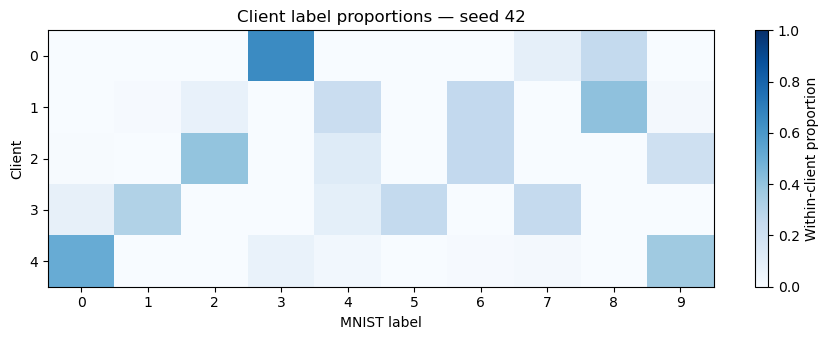

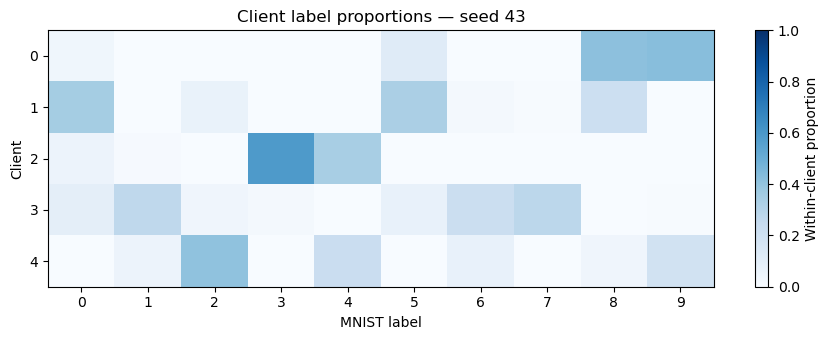

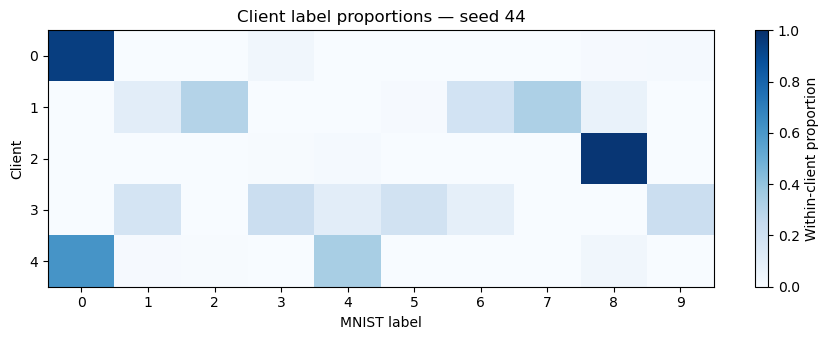

In [14]:
seed_artifacts = {
    seed: prepare_seed_artifacts(seed, train_dataset, CONFIG)
    for seed in CONFIG.seeds
}
partition_audit = pd.concat(
    [partition_audit_frame(artifacts) for artifacts in seed_artifacts.values()],
    ignore_index=True,
)
display(partition_audit)

for seed in CONFIG.seeds:
    plot_partition_heatmap(partition_audit.query("seed == @seed"), seed)

## 10. Evaluation and saving utilities (already implemented)

In [15]:
@torch.no_grad()
def accuracy_on_loader(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[int, int]:
    model.eval()
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions = model(inputs).argmax(dim=1)
        correct += int((predictions == targets).sum().item())
        total += int(targets.numel())
    return correct, total


def evaluate_clients(
    model: nn.Module, loaders: Mapping[int, DataLoader], device: torch.device
) -> pd.DataFrame:
    model = model.to(device)
    rows = []
    for client_id, loader in sorted(loaders.items()):
        correct, total = accuracy_on_loader(model, loader, device)
        rows.append({
            "client_id": int(client_id),
            "correct": correct,
            "total": total,
            "accuracy": correct / total,
        })
    return pd.DataFrame(rows)


def save_seed_artifacts(artifacts: SeedArtifacts, root: Path) -> Path:
    seed_dir = root / f"seed_{artifacts.seed:04d}"
    seed_dir.mkdir(parents=True, exist_ok=True)

    index_fields = ("partition_indices", "train_indices", "validation_indices", "test_indices")
    for field in index_fields:
        with (seed_dir / f"{field}.json").open("w", encoding="utf-8") as handle:
            json.dump(getattr(artifacts, field), handle, indent=2)

    with (seed_dir / "client_label_counts.json").open("w", encoding="utf-8") as handle:
        json.dump(artifacts.client_label_counts, handle, indent=2)

    torch.save(artifacts.initial_state_dict, seed_dir / "initial_model.pt")
    return seed_dir


for artifacts in seed_artifacts.values():
    save_seed_artifacts(artifacts, CONFIG.results_dir)

partition_audit.to_csv(CONFIG.results_dir / "partition_audit.csv", index=False)

## 11. TODO 2 — Connect one condition to the existing Notebook 05 runner

This is an adapter, not a new FL algorithm. It should call your existing runner and normalize its outputs into `ConditionResult`. Do not duplicate local training, FedProx loss, aggregation, or geometry code here.

Required `performance_history` columns: `round`, `weighted_validation_accuracy`. Required geometry columns for the final summary: `relative_update_magnitude`, a LOO-alignment column, and `cosine_similarity`.

In [16]:
print(inspect.signature(run_experiment))
print(inspect.getsource(run_experiment))

(config, mu_values, initial_model, train_ds, client_train_indices, validation_loaders, loss_fn, device, verbose: bool = False)
def run_experiment(
        config,
        mu_values,
        initial_model,
        train_ds,
        client_train_indices,
        validation_loaders,
        loss_fn,
        device,
        verbose: bool = False,
):
    performance_rows = []
    client_performance_rows = []
    client_update_rows = []
    pairwise_update_rows = []
    all_round_rows = []
    final_model_states: Dict[
        float,
        Dict[str, torch.Tensor],
    ] = {}
    for mu_value in mu_values:
        set_seed(config.seed)
        global_model = copy.deepcopy(initial_model).to(device)
        client_loaders = create_client_loaders(train_ds, client_train_indices, config.batch_size, config.seed, True)
        client_rows, summary = evaluate_client_loaders(global_model, validation_loaders, loss_fn, device)
        if verbose:
            print(
                f"mu={mu_value:g} | 

In [17]:
from dataclasses import asdict
from types import SimpleNamespace

def make_single_run_config(
    config: MultiSeedConfig,
    seed: int,
) -> SimpleNamespace:
    config_values = asdict(config)
    config_values["seed"] = seed
    return SimpleNamespace(**config_values)

In [18]:
print(inspect.getsource(run_experiment))

def run_experiment(
        config,
        mu_values,
        initial_model,
        train_ds,
        client_train_indices,
        validation_loaders,
        loss_fn,
        device,
        verbose: bool = False,
):
    performance_rows = []
    client_performance_rows = []
    client_update_rows = []
    pairwise_update_rows = []
    all_round_rows = []
    final_model_states: Dict[
        float,
        Dict[str, torch.Tensor],
    ] = {}
    for mu_value in mu_values:
        set_seed(config.seed)
        global_model = copy.deepcopy(initial_model).to(device)
        client_loaders = create_client_loaders(train_ds, client_train_indices, config.batch_size, config.seed, True)
        client_rows, summary = evaluate_client_loaders(global_model, validation_loaders, loss_fn, device)
        if verbose:
            print(
                f"mu={mu_value:g} | "
                f"round=00/{config.num_rounds:02d} | "
                f"validation_loss={summary['weighted_loss']:.4f} | "
 

In [27]:
def run_one_condition(
    *,
    seed: int,
    mu: float,
    initial_model: nn.Module,
    train_ds: Dataset,
    client_train_indices : Mapping[int, Sequence[int]],
    validation_loaders: Mapping[int, DataLoader],
    config: MultiSeedConfig,
    device: torch.device,
) -> ConditionResult:
    # TODO 2: Call run_experiment (or Notebook 05's single-condition helper)
    # using this model, these loaders, and exactly one mu. Then adapt the
    # returned models/DataFrames to ConditionResult.
    #
    # Important assertions to keep:
    # assert set(result.performance_history["seed"]) == {seed}
    # assert set(result.performance_history["mu"]) == {mu}
    single_config = make_single_run_config(config=config, seed=seed)
    loss_fn = nn.CrossEntropyLoss()

    start_time = time.perf_counter()

    run_result = run_experiment(
        config=single_config,
        mu_values=(mu,),
        initial_model=copy.deepcopy(initial_model),
        train_ds=train_ds,
        client_train_indices=client_train_indices,
        validation_loaders=validation_loaders,
        loss_fn=loss_fn,
        device=device,
        verbose=False,
    )

    runtime_seconds = time.perf_counter() - start_time

    assert float(mu) in run_result.final_model_states
    
    final_model = copy.deepcopy(initial_model)

    final_model.load_state_dict(
        run_result.final_model_states[float(mu)]
    )

    final_model = final_model.to(device)

    result = ConditionResult(
        seed=seed,
        mu=mu,
        final_model=final_model,
        performance_history = run_result.performance_history.copy(),
        client_performance_history = run_result.performance_history.copy(),
        client_diagnostics=run_result.client_update_diagnostics.copy(),
        pairwise_diagnostics=run_result.pairwise_update_diagnostics.copy(),
        round_diagnostics=run_result.round_diagnostics.copy(),
        runtime_seconds=runtime_seconds,
    )
    return result
    

## 12. Smoke test

Run this before the full experiment: one seed, two conditions, two rounds, and one local epoch.

In [28]:
SMOKE_CONFIG = replace(
    CONFIG,
    seeds=(42,),
    mu_values=(0.0, 0.1),
    num_rounds=2,
    local_epochs=1,
    results_dir=CONFIG.results_dir / "smoke_test",
)
SMOKE_CONFIG.results_dir.mkdir(parents=True, exist_ok=True)
SMOKE_CONFIG

MultiSeedConfig(seeds=(42,), mu_values=(0.0, 0.1), num_clients=5, alpha=0.1, local_epochs=1, num_rounds=2, batch_size=64, learning_rate=0.01, validation_fraction=0.1, test_fraction=0.1, num_workers=0, results_dir=WindowsPath('D:/HKU/New folder/federated-learning-under-heterogeneity-final/federated-learning-under-heterogeneity/results/multiseed_fedprox/smoke_test'))

In [29]:
def execute_condition(
    artifacts: SeedArtifacts, mu: float, dataset: Dataset, config: MultiSeedConfig
) -> tuple[ConditionResult, pd.DataFrame]:
    set_all_seeds(artifacts.seed)
    model = SimpleMLP(784,10)
    model.load_state_dict(copy.deepcopy(artifacts.initial_state_dict))

    expected_initial = state_dict_vector(artifacts.initial_state_dict)
    actual_initial = state_dict_vector(model.state_dict())
    assert torch.equal(expected_initial, actual_initial)

    _, validation_loaders, test_loaders = build_condition_loaders(
        artifacts, dataset, config
    )

    result = run_one_condition(
        seed=artifacts.seed,
        mu=mu,
        initial_model=model,
        train_ds=dataset,
        client_train_indices=artifacts.train_indices,
        validation_loaders=validation_loaders,
        config=config,
        device=DEVICE,
    )
    client_test = evaluate_clients(result.final_model, test_loaders, DEVICE)
    client_test.insert(0, "mu", mu)
    client_test.insert(0, "seed", artifacts.seed)
    return result, client_test


smoke_artifacts = prepare_seed_artifacts(42, train_dataset, SMOKE_CONFIG)
smoke_results = []
for mu in SMOKE_CONFIG.mu_values:
    condition_result, client_test = execute_condition(
        smoke_artifacts, mu, train_dataset, SMOKE_CONFIG
    )
    smoke_results.append((condition_result, client_test))

assert len(smoke_results) == 2
for result, client_test in smoke_results:
    assert np.isfinite(client_test["accuracy"]).all()
    assert client_test["total"].gt(0).all()
    assert not result.performance_history.empty
    assert np.isfinite(result.performance_history.select_dtypes(include="number")).all().all()

print("Smoke test passed.")

Smoke test passed.


## 13. Full multi-seed run

Run only after all reproducibility checks and the smoke test pass. Every completed condition is saved immediately so a disconnected session does not erase earlier work.

In [ ]:
all_performance = []
all_client_performance = []
all_client_diagnostics = []
all_pairwise_diagnostics = []
all_round_diagnostics = []
all_client_test = []
all_runtime = []

for seed in CONFIG.seeds:
    artifacts = seed_artifacts[seed]
    seed_dir = save_seed_artifacts(artifacts, CONFIG.results_dir)

    for mu in CONFIG.mu_values:
        print(f"Running seed={seed}, mu={mu}")
        result, client_test = execute_condition(artifacts, mu, train_dataset, CONFIG)

        all_client_performance.append(result.client_performance_history)
        all_round_diagnostics.append(result.round_diagnostics)
        all_performance.append(result.performance_history)
        all_client_diagnostics.append(result.client_diagnostics)
        all_pairwise_diagnostics.append(result.pairwise_diagnostics)
        all_client_test.append(client_test)
        all_runtime.append({"seed": seed, "mu": mu, "runtime_seconds": result.runtime_seconds})

        mu_tag = str(mu).replace(".", "p")
        result.performance_history.to_csv(seed_dir / f"performance_mu_{mu_tag}.csv", index=False)
        result.client_diagnostics.to_csv(seed_dir / f"client_diagnostics_mu_{mu_tag}.csv", index=False)
        result.pairwise_diagnostics.to_csv(seed_dir / f"pairwise_diagnostics_mu_{mu_tag}.csv", index=False)
        result.client_performance_history.to_csv(seed_dir / f"client_performance_mu_{mu_tag}.csv"),
        result.round_diagnostics.to_csv(seed_dir / f"round_diagnostics_mu_{mu_tag}.csv"),
        client_test.to_csv(seed_dir / f"final_client_test_mu_{mu_tag}.csv", index=False)
        torch.save(result.final_model.state_dict(), seed_dir / f"final_model_mu_{mu_tag}.pt")

performance_df = pd.concat(all_performance, ignore_index=True)
client_diagnostics_df = pd.concat(all_client_diagnostics, ignore_index=True)
pairwise_diagnostics_df = pd.concat(all_pairwise_diagnostics, ignore_index=True)
client_test_df = pd.concat(all_client_test, ignore_index=True)
client_performance_df = pd.concat(all_client_performance, ignore_index=True)
round_diagnostics_df = pd.concat(all_round_diagnostics, ignore_index=True)
runtime_df = pd.DataFrame(all_runtime)

performance_df.to_csv(CONFIG.results_dir / "performance_history.csv", index=False)
client_diagnostics_df.to_csv(CONFIG.results_dir / "client_update_diagnostics.csv", index=False)
pairwise_diagnostics_df.to_csv(CONFIG.results_dir / "pairwise_update_diagnostics.csv", index=False)
client_test_df.to_csv(CONFIG.results_dir / "final_client_test_metrics.csv", index=False)
runtime_df.to_csv(CONFIG.results_dir / "runtime.csv", index=False)
client_performance_df.to_csv(CONFIG.results_dir / "client_performance_history.csv",index=False,)
round_diagnostics_df.to_csv(CONFIG.results_dir / "round_diagnostics.csv",index=False,)

print("Full experiment finished and saved.")

## 14. Metric summaries (already implemented)

If Notebook 05 uses a different LOO-alignment column name, add it to the candidate list below.

In [ ]:
def first_existing_column(frame: pd.DataFrame, candidates: Sequence[str]) -> str:
    for column in candidates:
        if column in frame.columns:
            return column
    raise KeyError(f"None of these columns exist: {list(candidates)}")


def normalized_accuracy_auc(group: pd.DataFrame) -> float:
    ordered = group.sort_values("round")
    rounds = ordered["round"].to_numpy(dtype=float)
    accuracy = ordered["weighted_accuracy"].to_numpy(dtype=float)
    if len(rounds) < 2 or rounds[-1] == rounds[0]:
        return float(accuracy[-1])
    return float(np.trapz(accuracy, x=rounds) / (rounds[-1] - rounds[0]))


def build_seed_mu_summary(
    performance: pd.DataFrame,
    client_test: pd.DataFrame,
    client_diagnostics: pd.DataFrame,
    pairwise_diagnostics: pd.DataFrame,
    runtime: pd.DataFrame,
) -> pd.DataFrame:
    loo_column = first_existing_column(
        client_diagnostics,
        ("loo_alignment", "leave_one_out_alignment", "aggregate_alignment_loo"),
    )

    rows = []
    for (seed, mu), test_group in client_test.groupby(["seed", "mu"], sort=True):
        perf_group = performance.query("seed == @seed and mu == @mu")
        diag_group = client_diagnostics.query("seed == @seed and mu == @mu")
        pair_group = pairwise_diagnostics.query("seed == @seed and mu == @mu")
        runtime_value = runtime.query("seed == @seed and mu == @mu")["runtime_seconds"].iloc[0]

        rows.append({
            "seed": int(seed),
            "mu": float(mu),
            "final_weighted_test_accuracy": test_group["correct"].sum() / test_group["total"].sum(),
            "final_worst_client_accuracy": test_group["accuracy"].min(),
            "final_mean_client_accuracy": test_group["accuracy"].mean(),
            "client_accuracy_std": test_group["accuracy"].std(ddof=0),
            "normalized_validation_auc": normalized_accuracy_auc(perf_group),
            "median_relative_update_magnitude": diag_group["relative_update_magnitude"].median(),
            "mean_loo_alignment": diag_group[loo_column].mean(),
            "mean_pairwise_similarity": pair_group["cosine_similarity"].mean(),
            "runtime_seconds": float(runtime_value),
        })
    return pd.DataFrame(rows).sort_values(["seed", "mu"]).reset_index(drop=True)

In [ ]:
seed_mu_summary = build_seed_mu_summary(
    performance_df, client_test_df, client_diagnostics_df, pairwise_diagnostics_df, runtime_df
)
seed_mu_summary.to_csv(CONFIG.results_dir / "seed_mu_summary.csv", index=False)
display(seed_mu_summary)

metric_columns = [column for column in seed_mu_summary.columns if column not in {"seed", "mu"}]
across_seed_summary = (
    seed_mu_summary.groupby("mu")[metric_columns]
    .agg(["mean", "std"])
)
across_seed_summary.to_csv(CONFIG.results_dir / "across_seed_summary.csv")
display(across_seed_summary)

In [ ]:
def paired_difference_table(
    summary: pd.DataFrame, baseline_mu: float = 0.0, comparison_mu: float = 0.1
) -> pd.DataFrame:
    metrics = [
        "final_weighted_test_accuracy",
        "final_worst_client_accuracy",
        "final_mean_client_accuracy",
        "normalized_validation_auc",
    ]
    wide = summary.pivot(index="seed", columns="mu", values=metrics)
    difference = pd.DataFrame(index=wide.index)
    for metric in metrics:
        difference[f"{metric}_difference"] = (
            wide[(metric, comparison_mu)] - wide[(metric, baseline_mu)]
        )
    return difference.reset_index()


paired_differences = paired_difference_table(seed_mu_summary)
paired_differences.to_csv(CONFIG.results_dir / "paired_mu_0p1_minus_0p0.csv", index=False)
display(paired_differences)

## 15. Minimal plots (already implemented)

Use only plots that answer the research question: mean validation trajectory with seed variability, paired final-performance differences, and the magnitude/alignment trade-off.

In [ ]:
def plot_validation_trajectories(performance: pd.DataFrame) -> None:
    grouped = (
        performance.groupby(["mu", "round"])["weighted_accuracy"]
        .agg(["mean", "std"])
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(8, 5))
    for mu, group in grouped.groupby("mu"):
        x = group["round"].to_numpy()
        mean = group["mean"].to_numpy()
        std = group["std"].fillna(0).to_numpy()
        ax.plot(x, mean, label=f"mu={mu}")
        ax.fill_between(x, mean - std, mean + std, alpha=0.18)
    ax.set(title="Validation accuracy across seeds", xlabel="Round", ylabel="Weighted validation accuracy")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_paired_accuracy(summary: pd.DataFrame) -> None:
    selected = summary[summary["mu"].isin([0.0, 0.1])]
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for seed, group in selected.groupby("seed"):
        group = group.sort_values("mu")
        ax.plot(group["mu"], group["final_weighted_test_accuracy"], marker="o", label=f"seed {seed}")
    ax.set_xticks([0.0, 0.1], ["FedAvg", "FedProx (mu=0.1)"])
    ax.set_ylabel("Final weighted client-test accuracy")
    ax.set_title("Paired change within each seed")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_validation_trajectories(performance_df)
plot_paired_accuracy(seed_mu_summary)

## 16. Findings template

### Main result

Across three independently generated client populations, moderate FedProx (`mu = 0.1`) improved final weighted accuracy in **__/3 seeds**, worst-client accuracy in **__/3 seeds**, and normalized validation AUC in **__/3 seeds** relative to FedAvg.

The mean paired changes were **__** for final weighted accuracy, **__** for worst-client accuracy, and **__** for normalized validation AUC.

### Geometry

Increasing `mu` changed median relative update magnitude from **__** to **__** and mean LOO alignment from **__** to **__**. This [supports / does not support] the explanation that the performance difference is associated with reduced client drift.

### Interpretation

- If improvement occurs in 3/3 seeds: the result is directionally consistent, but more seeds are still required for a precise estimate.
- If improvement occurs in 2/3 seeds: moderate FedProx helps on average but is partition-dependent.
- If improvement occurs in 1/3 or 0/3 seeds: the seed-42 result does not replicate reliably.

### Limitations

This study uses only three seeds, five fully participating clients, one Dirichlet concentration, one MLP architecture, and preselected `mu` values. It supports a robustness check, not a universal claim about FedProx.